In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.append("../..")

from src.configs.settings import Settings
from src.filtration import filter_time_series
from src.ts_features import extract_features_for_groups

In [2]:
data_dir = Path("../../data")

settings = Settings()

In [3]:
mirrors_ts_df = pd.read_csv(data_dir / "processed" / "mirrors_ts.csv")

mirrors_products_characteristics_df = pd.read_csv(
    data_dir / "processed" / "mirrors_products_characteristics.csv"
)

In [4]:
mirrors_ts_df["date"] = pd.to_datetime(mirrors_ts_df["Месяц"])
drop_columns = ["INN", "Месяц", "Выручка FBO", "Выручка FBS", "Выручка", "Продажи FBO"]

mirrors_ts_df = mirrors_ts_df.drop(columns=drop_columns)
mirrors_ts_df = mirrors_ts_df.drop_duplicates()

rename_config = {"NM_ID": "article", "Продажи FBS": "sales"}
mirrors_ts_df = mirrors_ts_df.rename(columns=rename_config)

In [5]:
int_cols_rename = {
    "options_Габариты__Высота предмета": "height",
    "options_Габариты__Ширина предмета": "width",
    "options_Габариты__Вес без упаковки (кг)": "weight",
}

mirrors_products_characteristics_df = mirrors_products_characteristics_df.drop(columns=["subj_root_name"])
mirrors_products_characteristics_df = mirrors_products_characteristics_df.rename(columns=int_cols_rename)

int_cols = list(int_cols_rename.values())
mirrors_products_characteristics_df[int_cols] = mirrors_products_characteristics_df[int_cols].fillna(
    mirrors_products_characteristics_df[int_cols].median()
)

In [6]:
filtered_mirrors_ts_df = filter_time_series(mirrors_ts_df, settings.filtration)
filtered_mirrors_ts_df.to_csv(data_dir / "processed" / "filtered_mirrors_ts.csv", index=False)
print(f"Осталось {len(filtered_mirrors_ts_df) / len(mirrors_ts_df) * 100:.2f}% строк")

Осталось 11.15% строк


/home/nikita/projects/microniches/notebooks/niches/../../src/filtration.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.sort_values([group_col, date_col])


<Axes: >

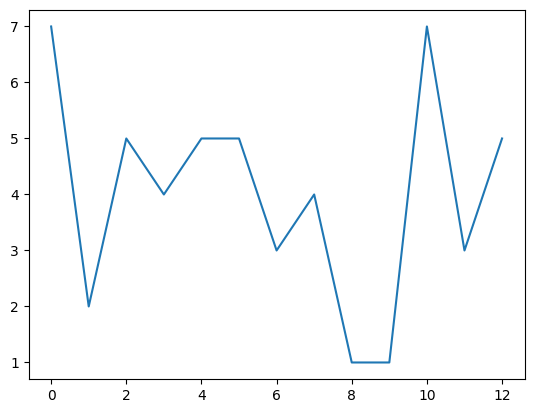

In [7]:
import random

nm_id = random.choice(filtered_mirrors_ts_df["article"].unique()).item()
product_df = (
    filtered_mirrors_ts_df[filtered_mirrors_ts_df["article"].eq(nm_id)]
    .sort_values(by=["date"])
    .reset_index(drop=True)
)
product_df["sales"].plot()

In [8]:
features_mirrors_ts_df = extract_features_for_groups(
    filtered_mirrors_ts_df, group_col="article", value_col="sales"
)
features_mirrors_ts_df = features_mirrors_ts_df.reset_index()

# Add Meta

In [9]:
features_mirrors_df = pd.merge(
    left=features_mirrors_ts_df,
    right=mirrors_products_characteristics_df,
    how="inner",
    on="article",
)

In [10]:
features_mirrors_df.to_csv(
    data_dir / "processed" / "features_mirrors.csv", index=False
)